# DAQ live plot

Currents over the switches, one time base, live.

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, simulated_device=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


The pins ride the same records as the analog fields, so every point on both is one window. `frames()` yields the last `window` seconds each time records arrive, indexed on seconds before now.

In [3]:
daq = device.daq
daq.open()
daq.enable()
device.set_time_from_pc(reference='pc')
daq.configure('phaseU', 'phaseV', 'phaseW', digital=True, sample_rate=50)
print(daq.channel_names())

['Phase U', 'Phase V', 'Phase W']


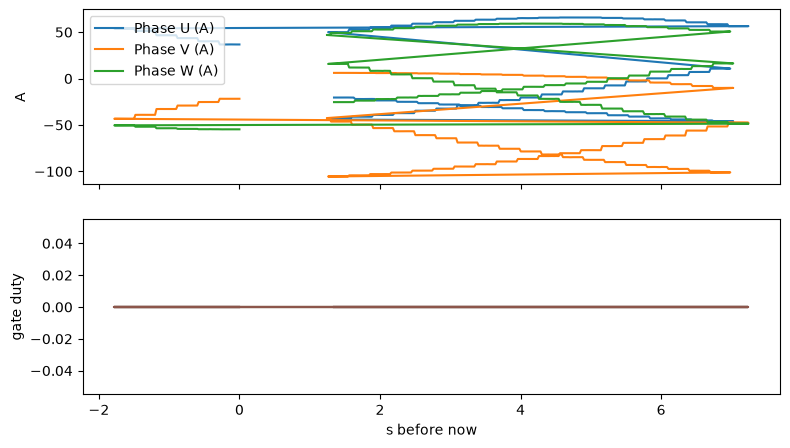

40 frames drawn; {'host': 0, 'peak': 0, 'dropped': 0, 'backlog': None, 'reads': 0, 'records': 0, 'rate': 0.0, 'lost': 0, 'cursor': 0}


In [4]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

daq.start()
frames = 0
for df in daq.frames(window=2.0, buffer=6.0, seconds=6.0, scaled=True):
    frames += 1
    clear_output(wait=True)
    fig, (top, bottom) = plt.subplots(2, 1, sharex=True, figsize=(9, 5))
    df[[c for c in df.columns if c.endswith('(A)')]].plot(ax=top)
    top.set_ylabel('A')
    df[[c for c in df.columns if c.startswith('TIM1_CH')]].plot(ax=bottom, legend=False)
    bottom.set_ylabel('gate duty')
    bottom.set_xlabel('s before now')
    plt.show()
daq.stop()
print(frames, 'frames drawn;', daq.buffered)

`history()` is the buffer behind the window, already a frame.

In [5]:
whole = daq.history(scaled=True)
print(len(whole), 'records held,', round(-whole.index.min(), 2), 's back')
device.close()

963 records held, 1.78 s back


## Conclusions

In [6]:
held = daq.buffered
print('frames drawn     %d in 6 s = %.1f /s' % (frames, frames / 6.0))
print('records          %d in the buffer, %.2f s deep' % (len(whole), -whole.index.min()))
print('reader           %d reads, %d records, %.1f records/s'
      % (held['reads'], held['records'], held['rate']))
print('host queue       %d waiting, peak %d, dropped %d'
      % (held['host'], held['peak'], held['dropped']))
print('board backlog    %s at the last read' % held['backlog'])
print('columns          %s' % ', '.join(c for c in whole.columns if c.endswith('(A)')))

frames drawn     40 in 6 s = 6.7 /s
records          963 in the buffer, 1.78 s deep
reader           0 reads, 0 records, 0.0 records/s
host queue       0 waiting, peak 0, dropped 0
board backlog    None at the last read
columns          Phase U (A), Phase V (A), Phase W (A)


`start()` puts a reader thread on the link and it is the only thing that touches the transport while it lives, so a `print` or a redraw in this loop never sits between two round trips. Every read answers its own backlog in the same transaction, so pacing costs no extra round trip.

What `frames()` yields is what is on screen, and `buffer` seconds are kept behind it - the buffer is records, so nothing is concatenated and nothing grows, and a plot that forgets to trim cannot become the bottleneck that fills the ring. The index is seconds before now, newest at 0, so the axis stands still while the data moves through it.

A ring is finite: a reader that falls far enough behind for the writer to lap it loses records and is told how many in `buffered['lost']`. A terminal that stopped drawing for six seconds once overflowed a 16 K ring - 334 records (FINDINGS).